# Santer & Poterjoy 2026 Likelihood Estimation LPF Experiments


In [6]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy

from DAPyr.MISC import rkhs_likelihood

reload(dap)

np.set_printoptions(suppress=True)


In [7]:
uoep = {'mu': 0, 'sigma': 2} 
poep = {'mu': 0, 'sigma': 2} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}


In [8]:
e_name = 'L96: sdg'
print(f'starting experiment {e_name}')
bw = 0.02
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_sd_kecd = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'h_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'compute_pyx_directly': False,
                       'force_hx_identity': False,
                       'Ne':80,
                       'T': 401,
                       'T_train': 400,
                       'train_frac': 1.0,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

e_sd_gauss = dap.Expt(e_name, {'expt_flag': 1,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'h_flag': 0,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'force_hx_identity': False,
                       'save_keest_pab':1,
                       'compute_pyx_directly': False,
                       'Ne':80,
                       'T': 1000,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

e_sd_true = dap.Expt(e_name, {'expt_flag': 1,
                       'model_flag':1,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'h_flag': 0,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 1,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep_sd,
                       'save_keest_pab':1,
                       'compute_pyx_directly': False,
                       'Ne':80,
                       'T': 1000,
                       'T_train': 400,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})

starting experiment L96: sdg


/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/__init__.py:411: UserWarning: (compute_pyx_directly, False) key-value pair not in available configurable parameters. Ignoring.
  warnings.warn('({}, {}) key-value pair not in available configurable parameters. Ignoring.'.format(key, val))
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/__init__.py:411: UserWarning: (force_hx_identity, False) key-value pair not in available configurable parameters. Ignoring.
  warnings.warn('({}, {}) key-value pair not in available configurable parameters. Ignoring.'.format(key, val))
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/__init__.py:411: UserWarning: (train_frac, 1.0) key-value pair not in available configurable parameters. Ignoring.
  warnings.warn('({}, {}) key-value pair not in available configurable parameters. Ignoring.'.format(key, val))
/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/__init__.py:411: UserWarning: (force_hx_identity, False) key-value pair not in ava

In [9]:
dap.runDA(e_sd_kecd)
#dap.runDA(e_sd_gauss)
#dap.runDA(e_sd_true)
print('done')


DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
done


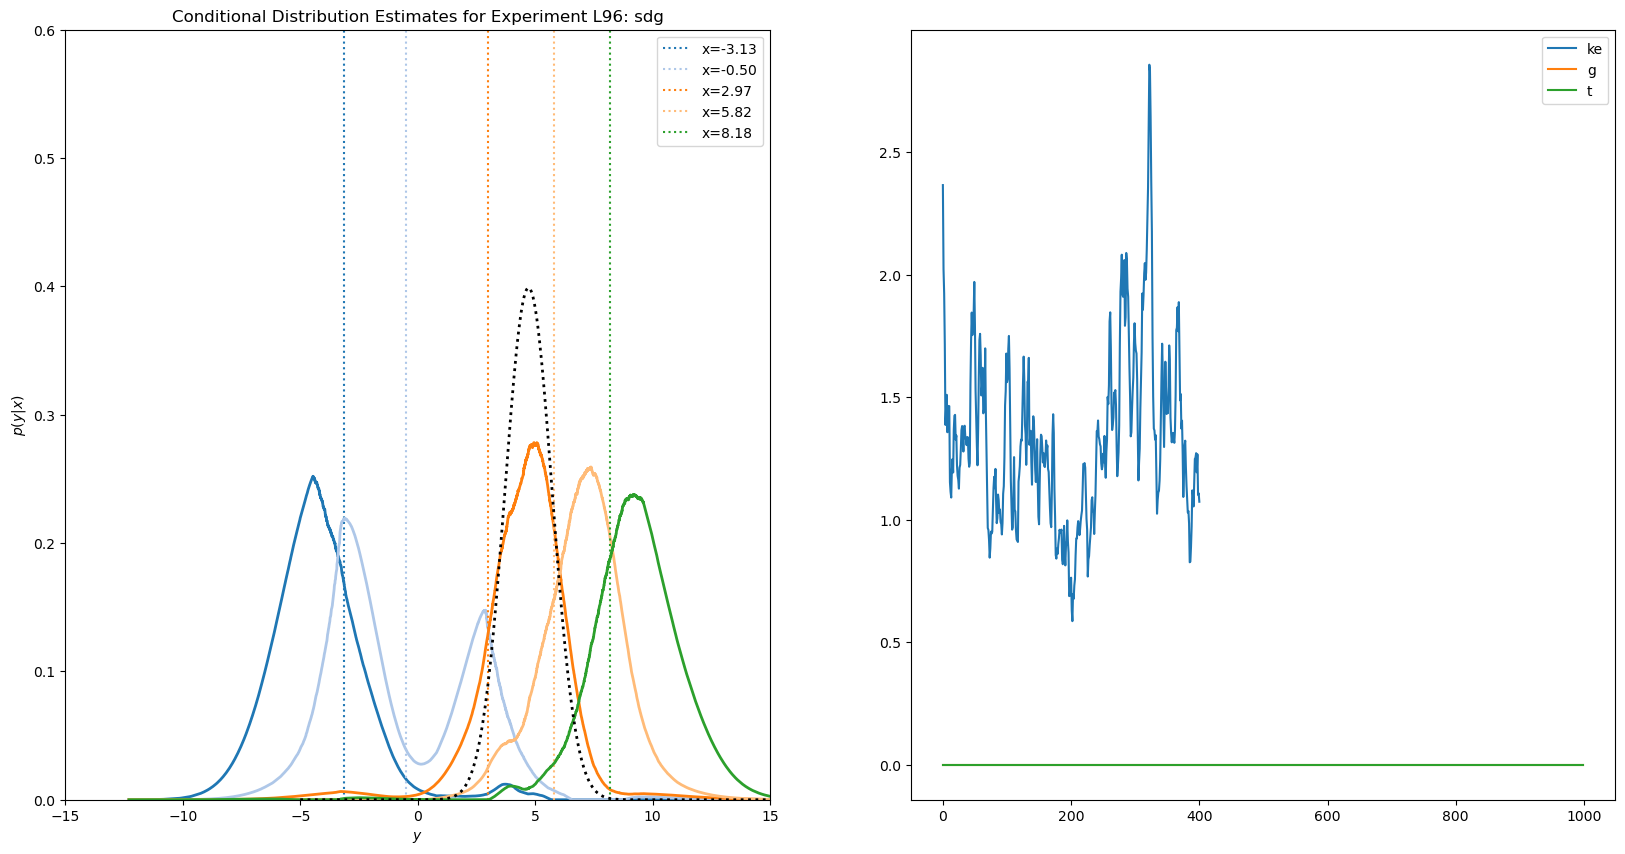

<Figure size 640x480 with 0 Axes>

In [10]:
fig, ax = plt.subplots(1,2, figsize=(20,10))
dap.plot_pab(e_sd_kecd, plot_states=True, ax=ax[0])
ax[0].plot(np.linspace(-5, 50, 1000), norm.pdf(np.linspace(-5, 50, 1000), loc=4.72, scale=1), linewidth=2, linestyle='dotted', c='k')
ax[0].set_ylim(0,0.6)
ax[0].set_xlim(-15,15)

ax[1].plot(e_sd_kecd.rmse, label='ke')
ax[1].plot(e_sd_gauss.rmse, label='g')
ax[1].plot(e_sd_true.rmse, label='t')
ax[1].legend()


In [273]:
e = dap.loadExpt('./data/experiments/l96-sdg-kecd-long-bad.expt')

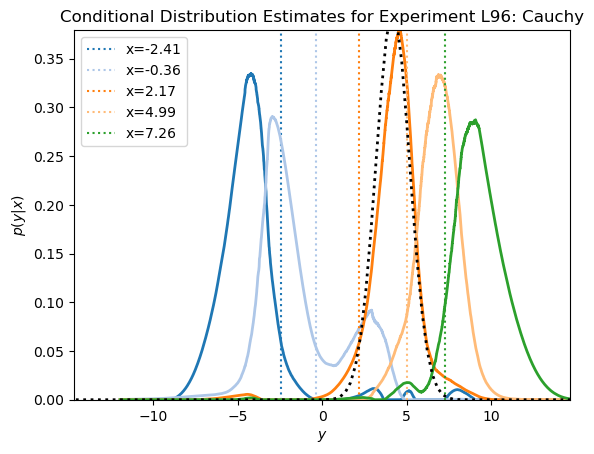

<Figure size 640x480 with 0 Axes>

In [278]:
fig, ax = plt.subplots()
dap.plot_pab(e, plot_states=True, ax=ax)
xtrain_50 = np.quantile(e.x_train, .50)
ax.plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=xtrain_50+2, scale=1), linewidth=2, linestyle='dotted', c='k')

In [279]:
xtrain_50

np.float64(2.1689410725778675)

In [281]:
import json
import base64
from PIL import Image
import io

# 1. Load the notebook
with open("../long_L96.ipynb", "r") as f:
    nb = json.load(f)

# 2. Search for images
for cell in nb.get("cells", []):
    for output in cell.get("outputs", []):
        if "data" in output and "image/png" in output["data"]:
            b64_data = output["data"]["image/png"]

            # If the base64 string is split across a list, join it
            if isinstance(b64_data, list):
                b64_data = "".join(b64_data)

            # 3. Decode and read with Pillow
            img_data = base64.b64decode(b64_data)
            img = Image.open(io.BytesIO(img_data))

            # 4. Print embedded metadata
            print("Found an image! Checking metadata...")
            print(img.info)
            print("-" * 30)

FileNotFoundError: [Errno 2] No such file or directory: '../long_L96.ipynb'